
# Random Forest — Task 2 Incident Classification
## Final aligned protocol

Three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

This notebook follows the aligned Task 2 benchmark protocol:

- same canonical dataset;
- same frozen grouped-random and spatial-holdout manifests;
- same 7-hour window: `t-3 ... t+3`;
- same primary traffic representation:
  1. `log1p(flow)`;
  2. pre-event-normalized relative change;
- three seeds: `42, 52, 62`;
- model selection by validation Macro-F1;
- final reporting as mean ± standard deviation across seeds.

For Random Forest, the 2 × 7 sequence is flattened and augmented with the same fixed summary features used by the aligned Decision Tree baseline.
No early stopping is used because Random Forest is not trained iteratively.


In [1]:

from pathlib import Path
import json
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

SEEDS = [42, 52, 62]
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]

DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")


OUTPUT_DIR = DATA_DIR / "random_forest_final_aligned_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR."
        )

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/andishahifahmuthahharah/Downloads/random_forest_final_aligned_outputs


## 1. Load and validate the frozen data

In [2]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

print("Integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


Integrity checks passed.


## 2. Build aligned traffic representation

In [3]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

TIME_NAMES = ["m3", "m2", "m1", "t0", "p1", "p2", "p3"]

def build_aligned_features(df: pd.DataFrame) -> pd.DataFrame:
    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    # Channel 1: measured log-flow
    log_flow = np.log1p(flow)

    # Channel 2: pre-event-normalized relative change
    baseline = np.median(flow[:, :3], axis=1, keepdims=True)
    rel_change = (flow - baseline) / (baseline + 1.0)
    rel_change = np.clip(rel_change, -5.0, 5.0)

    X = pd.DataFrame(index=df.index)

    # Flatten 2 x 7 representation
    for j, name in enumerate(TIME_NAMES):
        X[f"logflow_{name}"] = log_flow[:, j]
        X[f"relchg_{name}"] = rel_change[:, j]

    # Same fixed summary features as the aligned Decision Tree baseline
    pre = flow[:, :3]
    post = flow[:, 3:]

    X["pre_median"] = np.median(pre, axis=1)
    X["pre_mean"] = pre.mean(axis=1)
    X["post_mean"] = post.mean(axis=1)
    X["mean_shift"] = X["post_mean"] - X["pre_mean"]

    X["pre_slope"] = (flow[:, 2] - flow[:, 0]) / 2.0
    X["post_slope"] = (flow[:, 6] - flow[:, 3]) / 3.0
    X["onset_jump"] = flow[:, 3] - flow[:, 2]

    X["window_mean"] = flow.mean(axis=1)
    X["window_std"] = flow.std(axis=1)
    X["window_min"] = flow.min(axis=1)
    X["window_max"] = flow.max(axis=1)
    X["window_range"] = X["window_max"] - X["window_min"]

    diffs = np.diff(flow, axis=1)
    X["max_drop"] = np.minimum(diffs, 0).min(axis=1)
    X["max_rise"] = np.maximum(diffs, 0).max(axis=1)
    X["max_abs_change"] = np.abs(diffs).max(axis=1)
    X["cumulative_post_change"] = flow[:, 6] - flow[:, 3]

    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Engineered features contain NaN or infinite values.")

    return X.astype(np.float32)

X_preview = build_aligned_features(canonical)
print("Feature matrix shape:", X_preview.shape)
display(X_preview.head())


Feature matrix shape: (5265, 30)


,logflow_m3,relchg_m3,logflow_m2,relchg_m2,logflow_m1,relchg_m1,logflow_t0,relchg_t0,logflow_p1,relchg_p1,logflow_p2,relchg_p2,logflow_p3,relchg_p3,pre_median,pre_mean,post_mean,mean_shift,pre_slope,post_slope,onset_jump,window_mean,window_std,window_min,window_max,window_range,max_drop,max_rise,max_abs_change,cumulative_post_change
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.639057,0.000000,1.609438,-0.642857,2.639057,0.000000,2.397895,-0.214286,2.833213,0.214286,2.564949,-0.071429,2.079442,-0.428571,13.0,10.000000,11.25,1.250000,0.0,-1.000000,-3.0,10.714286,3.768830,4.0,16.0,12.0,-9.0,9.0,9.0,-3.0
3,0.000000,0.000000,0.000000,0.000000,3.465736,5.000000,2.995732,5.000000,3.433987,5.000000,3.332205,5.000000,0.000000,0.000000,0.0,10.333333,19.00,8.666667,15.5,-6.333333,-12.0,15.285714,13.708332,0.0,31.0,31.0,-27.0,31.0,31.0,-19.0
4,3.091043,-0.290323,3.433987,0.000000,3.526361,0.096774,3.555348,0.129032,4.304065,1.387097,4.663439,2.419355,5.081404,4.193548,30.0,28.000000,93.00,65.000000,6.0,42.000000,1.0,65.142860,47.561775,21.0,160.0,139.0,0.0,55.0,55.0,126.0


## 3. Compact Random Forest search space

In [4]:

PARAM_GRID = [
    {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features,
        "class_weight": class_weight,
    }
    for n_estimators in [300]
    for max_depth in [10, 20, None]
    for min_samples_leaf in [5, 10, 20]
    for min_samples_split in [10, 20]
    for max_features in ["sqrt", 0.5]
    for class_weight in ["balanced", "balanced_subsample"]
]

print("Parameter combinations:", len(PARAM_GRID))


Parameter combinations: 72


In [5]:

def merge_split(canonical_df, manifest):
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (merged["target_class"] == merged["target_class_manifest"]).all()

    return merged.drop(columns="target_class_manifest")

def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
        ),
    }


## 4. Run one seed

In [6]:

def run_one_seed(split_name, manifest, seed):
    random.seed(seed)
    np.random.seed(seed)

    data = merge_split(canonical, manifest)
    X = build_aligned_features(data)
    y = data["target_class"].astype(str)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train = X.loc[masks["train"]]
    X_val = X.loc[masks["validation"]]
    X_test = X.loc[masks["test"]]

    y_train = y.loc[masks["train"]]
    y_val = y.loc[masks["validation"]]
    y_test = y.loc[masks["test"]]

    search_rows = []
    models = []

    for i, params in enumerate(PARAM_GRID, start=1):
        model = RandomForestClassifier(
            criterion="gini",
            n_jobs=-1,
            random_state=seed,
            **params,
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)

        row = {
            **params,
            **metric_row(y_val, val_pred),
        }

        search_rows.append(row)
        models.append(model)

        if i % 20 == 0 or i == len(PARAM_GRID):
            print(
                f"{split_name} | seed {seed} | "
                f"evaluated {i}/{len(PARAM_GRID)} configurations"
            )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "n_estimators"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_params = PARAM_GRID[best_idx]

    partition_rows = []
    prediction_frames = []

    for part, X_part, y_part in [
        ("train", X_train, y_train),
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        pred = best_model.predict(X_part)

        partition_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            **metric_row(y_part, pred),
        })

        prediction_frames.append(pd.DataFrame({
            "event_sample_id": data.loc[masks[part], "event_sample_id"].to_numpy(),
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            "y_true": y_part.to_numpy(),
            "y_pred": pred,
        }))

    metrics_df = pd.DataFrame(partition_rows)
    predictions_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = predictions_df.loc[
        predictions_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T

    return {
        "model": best_model,
        "best_params": best_params,
        "search": search_df,
        "metrics": metrics_df,
        "predictions": predictions_df,
        "report": report_df,
        "feature_names": X.columns.tolist(),
    }


## 5. Run all 3 seeds for both split schemes

In [7]:

SPLITS = [
    ("Grouped-random", grouped_manifest),
    ("Spatial holdout", spatial_manifest),
]

all_metrics = []
all_predictions = []
all_reports = []
all_best_params = []
all_models = {}

for split_name, manifest in SPLITS:
    for seed in SEEDS:
        print(f"\nRunning {split_name} | seed {seed}")

        out = run_one_seed(
            split_name=split_name,
            manifest=manifest,
            seed=seed,
        )

        all_models[(split_name, seed)] = out["model"]
        all_metrics.append(out["metrics"])
        all_predictions.append(out["predictions"])

        report_tmp = out["report"].reset_index().rename(columns={"index": "class"})
        report_tmp["split_scheme"] = split_name
        report_tmp["seed"] = seed
        all_reports.append(report_tmp)

        all_best_params.append({
            "split_scheme": split_name,
            "seed": seed,
            **out["best_params"],
        })

        safe_split = split_name.lower().replace("-", "_").replace(" ", "_")

        out["search"].to_csv(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_hyperparameter_search.csv",
            index=False,
        )

        joblib.dump(
            out["model"],
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_random_forest.joblib",
        )

df_all_metrics = pd.concat(all_metrics, ignore_index=True)
df_all_predictions = pd.concat(all_predictions, ignore_index=True)
df_all_reports = pd.concat(all_reports, ignore_index=True)
df_best_params = pd.DataFrame(all_best_params)

df_all_metrics.to_csv(
    OUTPUT_DIR / "random_forest_all_metrics_per_seed.csv",
    index=False,
)
df_all_predictions.to_csv(
    OUTPUT_DIR / "random_forest_all_predictions.csv",
    index=False,
)
df_all_reports.to_csv(
    OUTPUT_DIR / "random_forest_all_classification_reports.csv",
    index=False,
)
df_best_params.to_csv(
    OUTPUT_DIR / "random_forest_best_params_per_seed.csv",
    index=False,
)

display(df_best_params)



Running Grouped-random | seed 42
Grouped-random | seed 42 | evaluated 20/72 configurations
Grouped-random | seed 42 | evaluated 40/72 configurations
Grouped-random | seed 42 | evaluated 60/72 configurations
Grouped-random | seed 42 | evaluated 72/72 configurations

Running Grouped-random | seed 52
Grouped-random | seed 52 | evaluated 20/72 configurations
Grouped-random | seed 52 | evaluated 40/72 configurations
Grouped-random | seed 52 | evaluated 60/72 configurations
Grouped-random | seed 52 | evaluated 72/72 configurations

Running Grouped-random | seed 62
Grouped-random | seed 62 | evaluated 20/72 configurations
Grouped-random | seed 62 | evaluated 40/72 configurations
Grouped-random | seed 62 | evaluated 60/72 configurations
Grouped-random | seed 62 | evaluated 72/72 configurations

Running Spatial holdout | seed 42
Spatial holdout | seed 42 | evaluated 20/72 configurations
Spatial holdout | seed 42 | evaluated 40/72 configurations
Spatial holdout | seed 42 | evaluated 60/72 confi

,split_scheme,seed,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,class_weight
0,Grouped-random,42,300,10.0,10,10,0.5,balanced
1,Grouped-random,52,300,10.0,5,20,0.5,balanced_subsample
2,Grouped-random,62,300,10.0,10,10,0.5,balanced_subsample
3,Spatial holdout,42,300,NaN,5,20,sqrt,balanced
4,Spatial holdout,52,300,NaN,5,10,sqrt,balanced_subsample
5,Spatial holdout,62,300,20.0,5,20,0.5,balanced


## 6. Final mean ± SD results

In [8]:

test_metrics = df_all_metrics[
    df_all_metrics["partition"].eq("test")
].copy()

summary = (
    test_metrics
    .groupby("split_scheme")
    .agg({
        "accuracy": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "macro_precision": ["mean", "std"],
        "macro_recall": ["mean", "std"],
        "macro_f1": ["mean", "std"],
        "weighted_f1": ["mean", "std"],
    })
)

summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns.to_flat_index()
]

summary = summary.reset_index()

summary.to_csv(
    OUTPUT_DIR / "random_forest_final_test_summary_mean_sd.csv",
    index=False,
)

print("Final Random Forest test results (mean ± SD across seeds 42, 52, 62):")
display(summary)


Final Random Forest test results (mean ± SD across seeds 42, 52, 62):


,split_scheme,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Grouped-random,0.495394,0.006447,0.356361,0.006447,0.356903,0.018673,0.356361,0.006447,0.344212,0.011839,0.505516,0.004150
1,Spatial holdout,0.458113,0.010610,0.352880,0.007840,0.339788,0.013666,0.352880,0.007840,0.316120,0.010284,0.469759,0.009912


## 7. Per-class mean ± SD

In [9]:

per_class = df_all_reports[
    df_all_reports["class"].isin(CLASS_ORDER)
].copy()

per_class_summary = (
    per_class
    .groupby(["split_scheme", "class"])
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1-score": ["mean", "std"],
        "support": ["mean"],
    })
)

per_class_summary.columns = [
    "_".join(col).strip("_")
    for col in per_class_summary.columns.to_flat_index()
]

per_class_summary = per_class_summary.reset_index()

per_class_summary.to_csv(
    OUTPUT_DIR / "random_forest_per_class_summary_mean_sd.csv",
    index=False,
)

display(per_class_summary)


,split_scheme,class,precision_mean,precision_std,recall_mean,recall_std,f1-score_mean,f1-score_std,support_mean
0,Grouped-random,ACCIDENT,0.135648,0.063386,0.067568,0.040541,0.089903,0.050173,74.0
1,Grouped-random,NORMAL,0.681185,0.004371,0.577942,0.012983,0.625286,0.008428,541.0
2,Grouped-random,OTHER_DISRUPTION,0.253874,0.009770,0.423573,0.017760,0.317448,0.012207,181.0
3,Spatial holdout,ACCIDENT,0.084643,0.030944,0.022523,0.015604,0.035185,0.022017,74.0
4,Spatial holdout,NORMAL,0.688930,0.007588,0.493204,0.014660,0.574809,0.011766,515.0
5,Spatial holdout,OTHER_DISRUPTION,0.245791,0.006268,0.542914,0.003457,0.338368,0.006609,167.0


## 8. Aggregate confusion matrices across 3 seeds

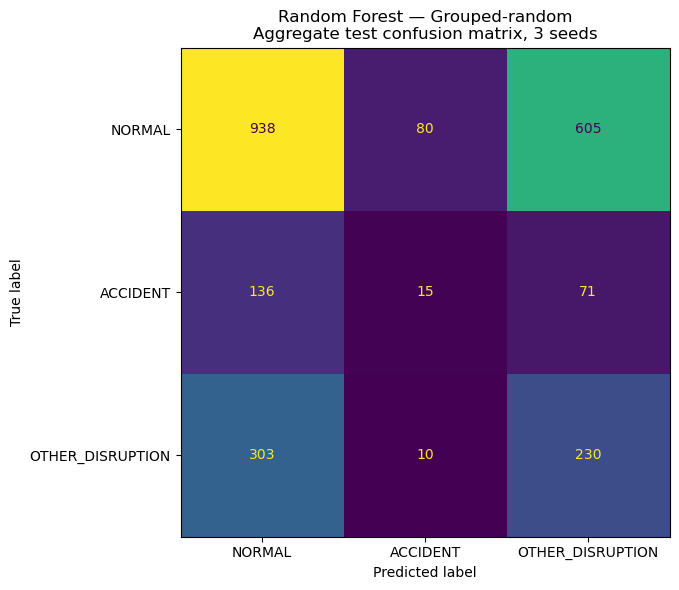

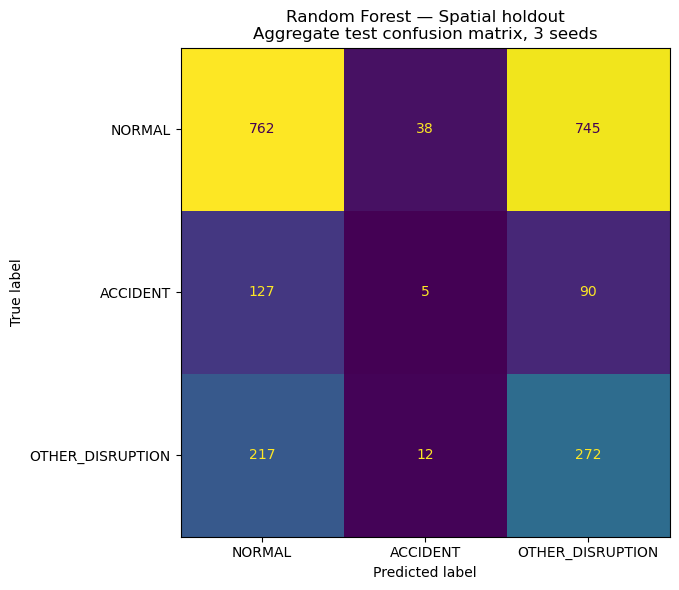

In [10]:

for split_name, _ in SPLITS:
    subset = df_all_predictions[
        (df_all_predictions["split_scheme"] == split_name)
        & (df_all_predictions["partition"] == "test")
    ]

    cm_sum = np.zeros((len(CLASS_ORDER), len(CLASS_ORDER)), dtype=int)

    for seed in SEEDS:
        seed_df = subset[subset["seed"] == seed]
        cm_sum += confusion_matrix(
            seed_df["y_true"],
            seed_df["y_pred"],
            labels=CLASS_ORDER,
        )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_sum,
        display_labels=CLASS_ORDER,
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Random Forest — {split_name}\nAggregate test confusion matrix, 3 seeds")
    fig.tight_layout()
    plt.show()


## 9. Feature importance

,split_scheme,feature,mean,std
18,Grouped-random,relchg_m1,0.049684,0.001445
20,Grouped-random,relchg_m3,0.048882,0.001441
12,Grouped-random,onset_jump,0.047113,0.000994
17,Grouped-random,pre_slope,0.043448,0.001113
21,Grouped-random,relchg_p1,0.041147,0.001184
24,Grouped-random,relchg_t0,0.040883,0.000263
9,Grouped-random,max_drop,0.040803,0.001512
0,Grouped-random,cumulative_post_change,0.040636,0.000514
14,Grouped-random,post_slope,0.039661,0.001016
10,Grouped-random,max_rise,0.037407,0.001246


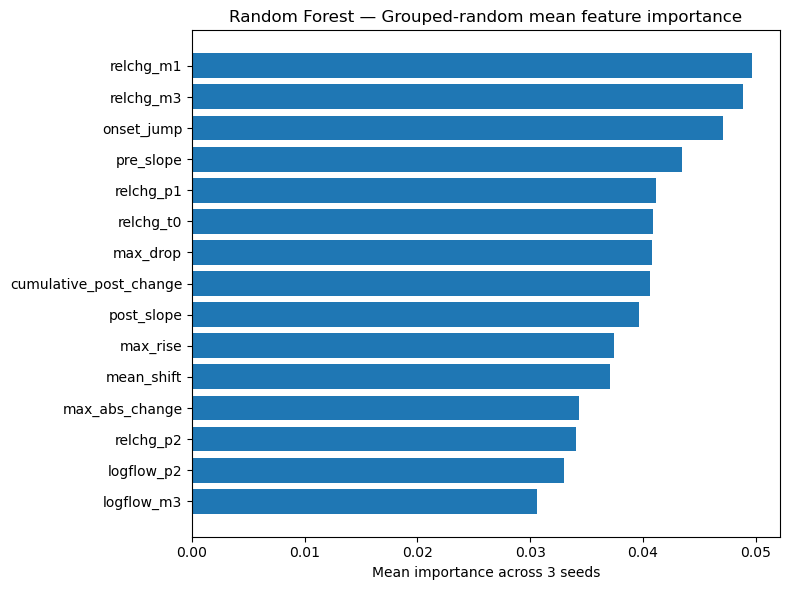

,split_scheme,feature,mean,std
50,Spatial holdout,relchg_m3,0.046580,0.006555
48,Spatial holdout,relchg_m1,0.042000,0.006527
39,Spatial holdout,max_drop,0.039298,0.004613
54,Spatial holdout,relchg_t0,0.038945,0.003852
51,Spatial holdout,relchg_p1,0.038909,0.003200
41,Spatial holdout,mean_shift,0.037080,0.001243
42,Spatial holdout,onset_jump,0.036814,0.002800
47,Spatial holdout,pre_slope,0.036610,0.001572
52,Spatial holdout,relchg_p2,0.036459,0.001566
44,Spatial holdout,post_slope,0.036415,0.000330


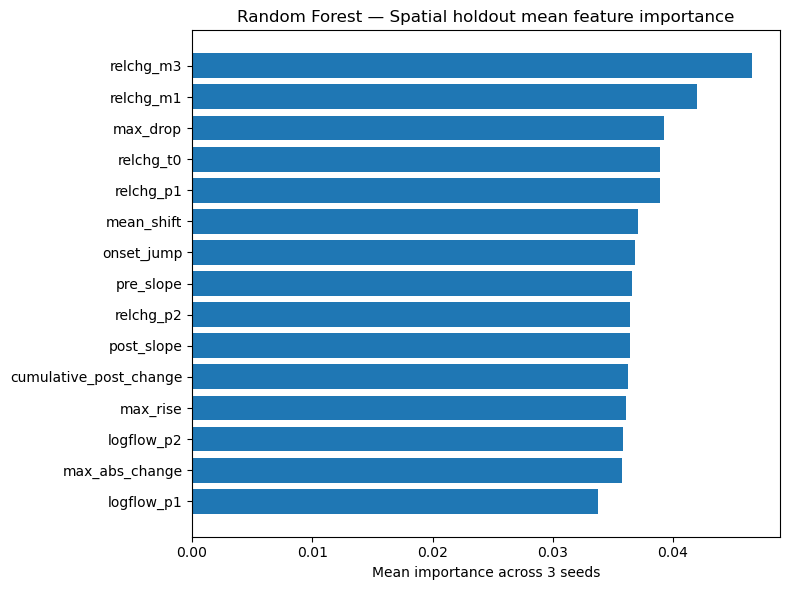

In [11]:

feature_names = build_aligned_features(canonical).columns.tolist()

importance_rows = []

for (split_name, seed), model in all_models.items():
    for feature, importance in zip(feature_names, model.feature_importances_):
        importance_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "feature": feature,
            "importance": importance,
        })

importance_df = pd.DataFrame(importance_rows)

importance_summary = (
    importance_df
    .groupby(["split_scheme", "feature"])["importance"]
    .agg(["mean", "std"])
    .reset_index()
)

importance_summary.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance_mean_sd.csv",
    index=False,
)

for split_name, _ in SPLITS:
    top = (
        importance_summary[importance_summary["split_scheme"] == split_name]
        .sort_values("mean", ascending=False)
        .head(15)
        .sort_values("mean")
    )

    display(top.sort_values("mean", ascending=False))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["mean"])
    ax.set_title(f"Random Forest — {split_name} mean feature importance")
    ax.set_xlabel("Mean importance across 3 seeds")
    fig.tight_layout()
    plt.show()



## Reporting guidance

Use these two files for the final benchmark table and class-level interpretation:

- `random_forest_final_test_summary_mean_sd.csv`
- `random_forest_per_class_summary_mean_sd.csv`

Primary metric:
- test Macro-F1 mean ± SD across seeds 42, 52, and 62.

Random Forest does not use early stopping. Model complexity and imbalance are controlled through:
- number of trees;
- maximum depth;
- minimum samples per leaf;
- minimum samples to split;
- feature subsampling;
- balanced class weighting.

The test set is never used during hyperparameter selection.
